# Notebook 05: Historical Trajectory & Renewable Share

**One Sensor, One Year — Edition 2: Texas Grid**

2025 is one frame — the 19-year film tells the story. From 2007 (wind just emerging, no solar, no biomass reporting) through 2011 (solar first appears), 2016 (gas-CC dominance solidifies), 2022 (WSL storage added to reporting), to 2025 (wind + solar overtake coal).

**Inputs:**
- `../data/raw/FuelMixReport_PreviousYears.zip` — 18 XLSX files, 2007–2024, already extracted by this notebook to `previous_years/`
- `../data/processed/texas_2025_daily.csv` — current year (from N01)

**Outputs:**
- `../data/processed/texas_annual_history.csv` — canonical 2007–2025 annual-by-fuel table
- `../data/processed/trajectory.png` — static stacked-area historical chart
- `../../web/trajectory.html` — interactive plotly line chart (self-contained, CDN plotly JS)

**Format landscape** (ERCOT changed the report schema several times):
| Years | Sheet names | Key column | Fuel list |
|---|---|---|---|
| 2007 | `Dec2007` | `Date - Fuel`, `Daily MWH` | Coal, Gas, Hydro, Nuclear, Oth, Wnd (no solar, no biomass) |
| 2008–2010 | `Dec08` … `Dec10` | `Date-Fuel`, `Total` | + Gas_CC + Gas_GT split (still no solar) |
| 2011 | `Dec11` | `Date-Fuel`, `Total` | + Sun, Biomass first appear |
| 2012–2016 | `Dec12` … `Dec16` | `Date-Fuel`, `Total` | 9 fuels, names stabilize |
| 2017–2021 | `Jan` … `Dec` | `Date`, `Fuel`, `Total` (wide) | 9 fuels, modern format |
| 2022–2025 | `Jan` … `Dec` | same | + WSL storage |

In [1]:
from pathlib import Path
import re
import zipfile
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

RAW = Path('../data/raw')
PROCESSED = Path('../data/processed')
WEB = Path('../web')
HISTORY_DIR = RAW / 'previous_years'
HISTORY_ZIP = RAW / 'FuelMixReport_PreviousYears.zip'

WEB.mkdir(parents=True, exist_ok=True)

# Extract the historical zip on first run
if not HISTORY_DIR.exists() or not any(HISTORY_DIR.iterdir()):
    print(f'Extracting {HISTORY_ZIP} ...')
    HISTORY_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(HISTORY_ZIP) as z:
        z.extractall(HISTORY_DIR)
    print(f'Extracted {sum(1 for _ in HISTORY_DIR.iterdir())} files')
else:
    n = sum(1 for _ in HISTORY_DIR.iterdir())
    print(f'Historical files already extracted: {n} files in {HISTORY_DIR}')

# Texas palette (same as N01–N04)
fuel_colors = {
    'coal':    '#D4890E',
    'gas':     '#E8A94A',
    'gas_cc':  '#F0C078',
    'nuclear': '#2A9D8F',
    'hydro':   '#264653',
    'wind':    '#72B352',
    'solar':   '#F4C430',
    'biomass': '#8B6F47',
    'other':   '#9B72CF',
    'wsl':     '#A0A0A0',
}
fuel_labels = {
    'coal': 'Coal', 'gas': 'Gas (simple)', 'gas_cc': 'Gas-CC',
    'nuclear': 'Nuclear', 'hydro': 'Hydro', 'wind': 'Wind',
    'solar': 'Solar', 'biomass': 'Biomass', 'other': 'Other',
    'wsl': 'Storage (WSL)',
}

Historical files already extracted: 18 files in ../data/raw/previous_years


## 1. Fuel name normalization

ERCOT used 3 different naming conventions between 2007 and 2025. Collapse them all to the same canonical set.

In [2]:
# Map every historical spelling to our canonical names
FUEL_NORMALIZE = {
    # Old 2007-format
    'Wnd': 'wind', 'Oth': 'other',
    # 2008-2010: gas split into CC + GT
    'Gas_CC': 'gas_cc',
    'Gas_GT': 'gas',        # simple-cycle / gas turbine peakers
    # 2011 transitional names
    'Sun': 'solar',
    # Modern stable names
    'Coal': 'coal', 'Gas': 'gas', 'Gas-CC': 'gas_cc',
    'Nuclear': 'nuclear', 'Hydro': 'hydro',
    'Wind': 'wind', 'Solar': 'solar',
    'Biomass': 'biomass', 'Other': 'other',
    'WSL': 'wsl',
}

def normalize_fuel(name):
    name = str(name).strip()
    return FUEL_NORMALIZE.get(name, name.lower())

## 2. Parser — per-sheet dispatch

Two sheet layouts coexist in the historical archive, and they don't follow year boundaries cleanly — **2011** used the modern `Date, Fuel, Total` columns while **2012–2016** reverted to the composite `Date-Fuel` key. So we dispatch per sheet, not per year, by looking at column names.

In [3]:
MONTH_PREFIXES = ('Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                  'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec')

def is_month_sheet(name: str) -> bool:
    return isinstance(name, str) and name[:3] in MONTH_PREFIXES

def parse_composite_sheet(df: pd.DataFrame) -> pd.DataFrame:
    # Old layout: first col is 'Date-Fuel' / 'Date - Fuel' / 'DateFuel',
    # second col is 'Total' or 'Daily MWH'.
    key_col = df.columns[0]
    total_col = df.columns[1]
    rows = []
    for key, total in zip(df[key_col], df[total_col]):
        if pd.isna(key) or pd.isna(total):
            continue
        text = str(key)
        parts = re.split(r'\s*[-_]\s*', text, maxsplit=1)
        if len(parts) != 2:
            continue
        date_str, fuel_raw = parts
        date = pd.to_datetime(date_str.strip(), format='%m/%d/%y', errors='coerce')
        if pd.isna(date):
            date = pd.to_datetime(date_str.strip(), errors='coerce')
        if pd.isna(date):
            continue
        try:
            mwh = float(total)
        except (TypeError, ValueError):
            continue
        rows.append({'date': date,
                     'fuel': normalize_fuel(fuel_raw),
                     'mwh': mwh})
    return pd.DataFrame(rows)

def parse_wide_sheet(df: pd.DataFrame) -> pd.DataFrame:
    # Modern layout: separate Date, Fuel, Total columns.
    d = df[['Date', 'Fuel', 'Total']].copy()
    d['Date'] = pd.to_datetime(d['Date'], errors='coerce')
    d['fuel'] = d['Fuel'].map(normalize_fuel)
    d = d.rename(columns={'Date': 'date', 'Total': 'mwh'})
    return d[['date', 'fuel', 'mwh']].dropna(subset=['date', 'mwh'])

def parse_year(path: Path, year: int) -> pd.DataFrame:
    # Per-sheet dispatch: 2011 uses the modern layout while 2012-2016 revert
    # to the composite format, so we check columns per sheet.
    engine = 'xlrd' if path.suffix == '.xls' else 'openpyxl'
    xl = pd.ExcelFile(path, engine=engine)
    month_sheets = [s for s in xl.sheet_names if is_month_sheet(s)]
    frames = []
    for sheet in month_sheets:
        df = pd.read_excel(path, sheet_name=sheet, engine=engine)
        if df.empty:
            continue
        if {'Date', 'Fuel', 'Total'}.issubset(df.columns):
            frames.append(parse_wide_sheet(df))
        else:
            frames.append(parse_composite_sheet(df))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

## 3. Run the parsers across all 18 historical files

In [4]:
history_files = sorted(HISTORY_DIR.glob('IntGen*'))
print(f'{len(history_files)} files to parse')

all_daily = []
for f in history_files:
    m = re.search(r'(\d{4})', f.name)
    if not m:
        print(f'  SKIP {f.name} (no year)')
        continue
    year = int(m.group(1))
    df = parse_year(f, year)
    if df.empty:
        print(f'  {year}: EMPTY')
        continue
    df['year'] = year
    all_daily.append(df)
    fuels = sorted(df['fuel'].unique())
    print(f'  {year}: {len(df):,} rows, {len(fuels)} fuels: {fuels}')

historical_daily = pd.concat(all_daily, ignore_index=True)
print(f'\nTotal: {len(historical_daily):,} rows spanning {historical_daily["year"].min()}–{historical_daily["year"].max()}')

18 files to parse


  2007: 2,190 rows, 6 fuels: ['coal', 'gas', 'hydro', 'nuclear', 'other', 'wind']


  2008: 2,227 rows, 7 fuels: ['coal', 'gas', 'gas_cc', 'hydro', 'nuclear', 'other', 'wind']


  2009: 2,555 rows, 7 fuels: ['coal', 'gas', 'gas_cc', 'hydro', 'nuclear', 'other', 'wind']


  2010: 2,555 rows, 7 fuels: ['coal', 'gas', 'gas_cc', 'hydro', 'nuclear', 'other', 'wind']


...

  2020: 3,294 rows, 9 fuels: ['biomass', 'coal', 'gas', 'gas_cc', 'hydro', 'nuclear', 'other', 'solar', 'wind']


  2021: 3,285 rows, 9 fuels: ['biomass', 'coal', 'gas', 'gas_cc', 'hydro', 'nuclear', 'other', 'solar', 'wind']


  2022: 3,650 rows, 10 fuels: ['biomass', 'coal', 'gas', 'gas_cc', 'hydro', 'nuclear', 'other', 'solar', 'wind', 'wsl']


  2023: 3,650 rows, 10 fuels: ['biomass', 'coal', 'gas', 'gas_cc', 'hydro', 'nuclear', 'other', 'solar', 'wind', 'wsl']


  2024: 3,660 rows, 10 fuels: ['biomass', 'coal', 'gas', 'gas_cc', 'hydro', 'nuclear', 'other', 'solar', 'wind', 'wsl']

Total: 56,301 rows spanning 2007–2024


## 4. Roll up to annual totals per fuel + append 2025

In [5]:
# Aggregate historical 2007-2024 to annual TWh per fuel
annual_hist = (
    historical_daily
    .groupby(['year', 'fuel'])['mwh']
    .sum()
    .div(1e6)                                # MWh → TWh
    .unstack('fuel', fill_value=0.0)
    .sort_index()
)

# Append 2025 from the daily CSV we built in N01
daily_2025 = pd.read_csv(PROCESSED / 'texas_2025_daily.csv', parse_dates=['Date'], index_col='Date')
FUEL_COLS_2025 = ['coal', 'gas', 'gas_cc', 'nuclear', 'hydro', 'wind', 'solar', 'biomass', 'other', 'wsl']
annual_2025 = (daily_2025[FUEL_COLS_2025].sum() / 1e6).to_frame().T
annual_2025.index = [2025]
annual_2025.index.name = 'year'

annual = pd.concat([annual_hist, annual_2025], axis=0).fillna(0.0).sort_index()

# Order columns for readability
ORDERED = ['coal', 'gas', 'gas_cc', 'nuclear', 'hydro', 'wind', 'solar', 'biomass', 'other', 'wsl']
annual = annual[[c for c in ORDERED if c in annual.columns]]

# Aggregates
annual['gas_total'] = annual[['gas', 'gas_cc']].sum(axis=1)
GEN_COLS = ['coal', 'gas_total', 'nuclear', 'hydro', 'wind', 'solar', 'biomass', 'other']
annual['total'] = annual[GEN_COLS].sum(axis=1)

print('Annual TWh by fuel (2007–2025):')
print(annual.round(1).to_string())

# Save
out_csv = PROCESSED / 'texas_annual_history.csv'
annual.to_csv(out_csv)
print(f'\nSaved {out_csv} ({len(annual)} years × {len(annual.columns)} cols)')

Annual TWh by fuel (2007–2025):
       coal    gas  gas_cc  nuclear  hydro   wind  solar  biomass  other  wsl  gas_total  total
year                                                                                           
2007  113.9  135.7     0.0     40.9    1.3    8.8    0.0      0.0    4.0  0.0      135.7  304.6
2008  114.7  126.0     6.7     40.7    0.8   15.2    0.0      0.0    4.8  0.0      132.7  309.0
2009  111.8   29.5    99.1     41.5    0.7   18.8    0.0      0.0    4.1  0.0      128.6  305.4
2010  124.9   25.2    95.3     41.3    0.9   24.7    0.0      0.0    3.7  0.0      120.5  316.0
2011  130.1   20.4   112.4     39.6    0.5   28.3    0.0      0.2    0.3  0.0      132.9  332.0
2012  109.7   21.7   123.3     38.4    0.5   29.8    0.1      0.5    0.2  0.0      145.0  324.3
2013  123.2   19.9   114.2     38.3    0.3   32.7    0.1      0.4    0.6  0.0      134.2  329.8
2014  122.5   18.1   121.6     39.3    0.2   36.1    0.3      0.6    0.0  0.0      139.8  338.8
2015   9

## 5. Validation — does 2025 in this table match N01's 494.8 TWh?

In [6]:
total_2025 = annual.loc[2025, 'total']
expected_2025 = 494.8  # from N01 / N02
delta = total_2025 - expected_2025
print(f'2025 total from historical table: {total_2025:.1f} TWh')
print(f'2025 total from N01/N02:          {expected_2025:.1f} TWh')
print(f'Delta: {delta:+.1f} TWh ({delta/expected_2025*100:+.2f}%)')
assert abs(delta) < 1.0, 'Mismatch between historical roll-up and N01 numbers'

# Sanity-check a couple of historical years
print()
print('Peak year by total generation:', annual['total'].idxmax(),
      f'({annual["total"].max():.0f} TWh)')
print('Lowest year:                   ', annual['total'].idxmin(),
      f'({annual["total"].min():.0f} TWh)')
print()
print('Fuel presence by year:')
for year in sorted(annual.index):
    present = [f for f in ['coal','gas','gas_cc','wind','solar','biomass','wsl']
               if annual.loc[year, f] > 0.01]
    print(f'  {year}: {present}')

2025 total from historical table: 494.8 TWh
2025 total from N01/N02:          494.8 TWh
Delta: -0.0 TWh (-0.01%)

Peak year by total generation: 2025 (495 TWh)
Lowest year:                    2007 (305 TWh)

Fuel presence by year:
  2007: ['coal', 'gas', 'wind']
  2008: ['coal', 'gas', 'gas_cc', 'wind']
  2009: ['coal', 'gas', 'gas_cc', 'wind']
  2010: ['coal', 'gas', 'gas_cc', 'wind']
  2011: ['coal', 'gas', 'gas_cc', 'wind', 'solar', 'biomass']
  2012: ['coal', 'gas', 'gas_cc', 'wind', 'solar', 'biomass']
  2013: ['coal', 'gas', 'gas_cc', 'wind', 'solar', 'biomass']
  2014: ['coal', 'gas', 'gas_cc', 'wind', 'solar', 'biomass']
  2015: ['coal', 'gas', 'gas_cc', 'wind', 'solar', 'biomass']
  2016: ['coal', 'gas', 'gas_cc', 'wind', 'solar', 'biomass']
  2017: ['coal', 'gas', 'gas_cc', 'wind', 'solar', 'biomass']
  2018: ['coal', 'gas', 'gas_cc', 'wind', 'solar', 'biomass']
  2019: ['coal', 'gas', 'gas_cc', 'wind', 'solar', 'biomass']
  2020: ['coal', 'gas', 'gas_cc', 'wind', 'solar', 'b

## 6. Static chart — stacked area of annual generation mix 2007–2025

The classic "watch the story unfold" chart. Coal shrinks, wind explodes, solar emerges from zero, gas takes over.

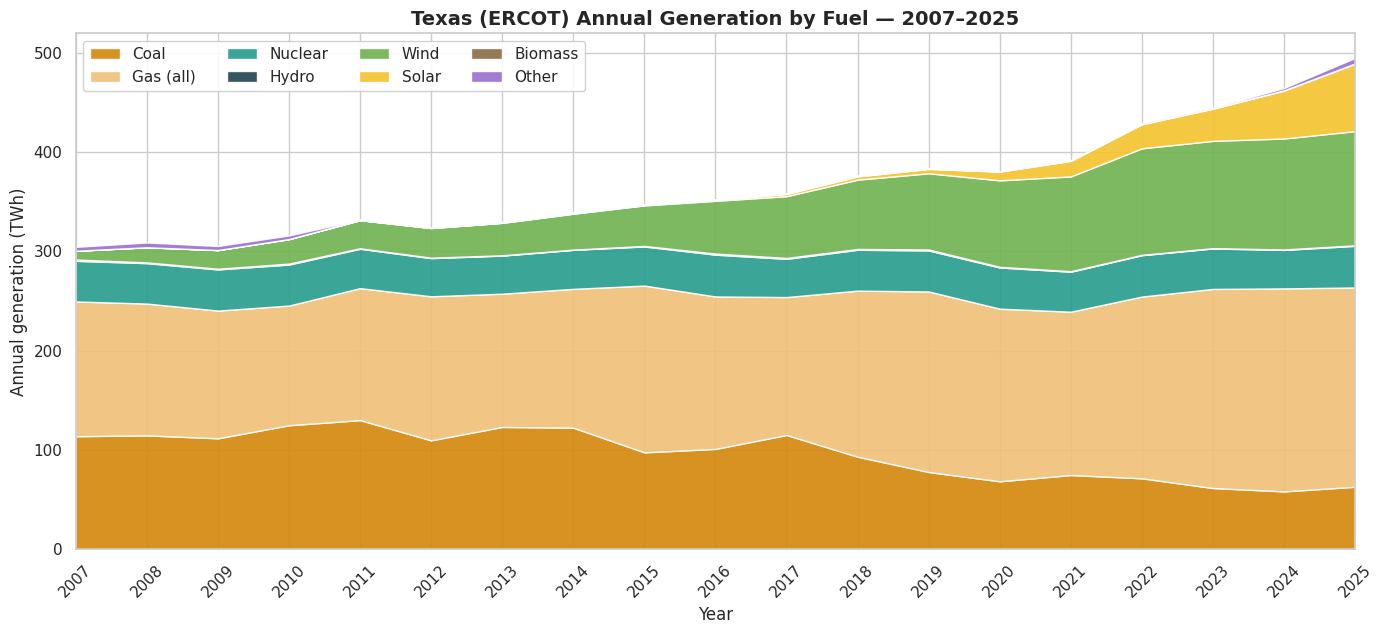

Saved ../data/processed/trajectory.png


In [7]:
STACK_ORDER = ['coal', 'gas_total', 'nuclear', 'hydro', 'wind', 'solar', 'biomass', 'other']
stack_labels = {
    'gas_total': 'Gas (all)',
    **{k: fuel_labels[k] for k in STACK_ORDER if k != 'gas_total'},
}
stack_colors = {
    'gas_total': fuel_colors['gas_cc'],
    **{k: fuel_colors[k] for k in STACK_ORDER if k != 'gas_total'},
}

plot_data = annual[STACK_ORDER]

fig, ax = plt.subplots(figsize=(14, 6.5))
ax.stackplot(
    plot_data.index,
    *[plot_data[c] for c in STACK_ORDER],
    labels=[stack_labels[c] for c in STACK_ORDER],
    colors=[stack_colors[c] for c in STACK_ORDER],
    alpha=0.92,
)
ax.set_xlabel('Year')
ax.set_ylabel('Annual generation (TWh)')
ax.set_title('Texas (ERCOT) Annual Generation by Fuel — 2007–2025',
             fontsize=14, fontweight='bold')
ax.set_xlim(annual.index.min(), annual.index.max())
ax.set_xticks(annual.index)
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper left', ncol=4, framealpha=0.9)

plt.tight_layout()
plt.savefig(PROCESSED / 'trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {PROCESSED / "trajectory.png"}')

## 7. The crossover moment — when did wind+solar pass coal in Texas?

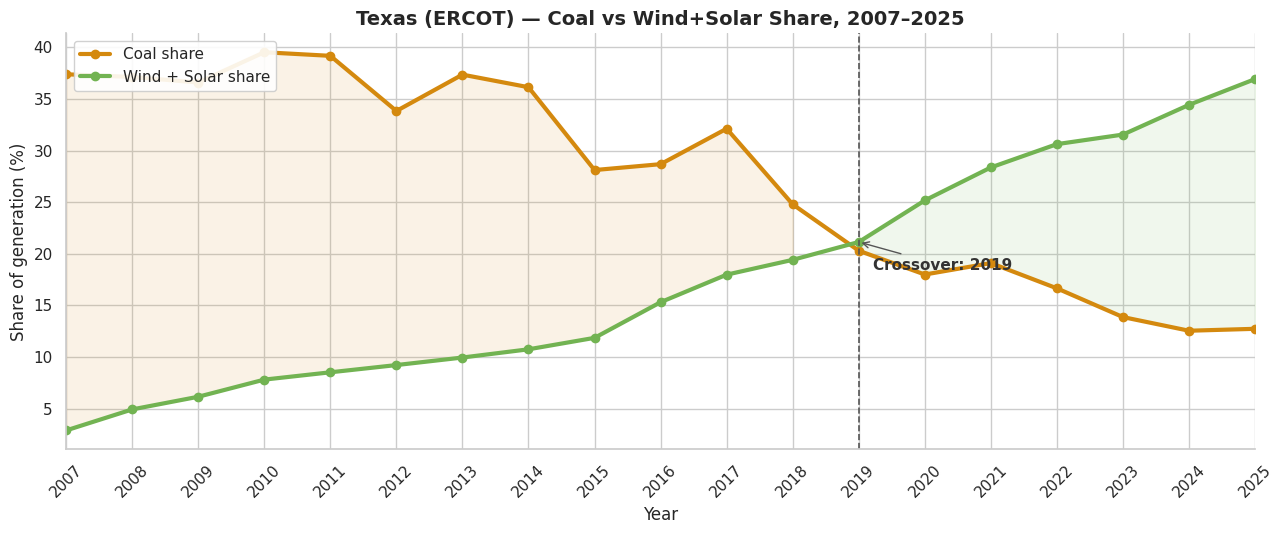

Wind + Solar first exceeded Coal in 2019.
  2007 coal share: 37.4%, wind+solar share: 2.90%
  2025 coal share: 12.7%, wind+solar share: 36.9%


In [8]:
clean_share_pct = (annual[['wind', 'solar']].sum(axis=1) / annual['total']) * 100
coal_share_pct = (annual['coal'] / annual['total']) * 100

diff = clean_share_pct - coal_share_pct
crossover_years = diff[diff > 0].index
crossover_year = int(crossover_years.min()) if len(crossover_years) else None

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(annual.index, coal_share_pct, color=fuel_colors['coal'],
        linewidth=3, marker='o', label='Coal share')
ax.plot(annual.index, clean_share_pct, color=fuel_colors['wind'],
        linewidth=3, marker='o', label='Wind + Solar share')
ax.fill_between(annual.index, clean_share_pct, coal_share_pct,
                where=(clean_share_pct < coal_share_pct),
                color=fuel_colors['coal'], alpha=0.10)
ax.fill_between(annual.index, clean_share_pct, coal_share_pct,
                where=(clean_share_pct >= coal_share_pct),
                color=fuel_colors['wind'], alpha=0.10)

if crossover_year is not None:
    y_val = float(clean_share_pct.loc[crossover_year])
    ax.axvline(crossover_year, color='#555', linestyle='--', linewidth=1.2)
    ax.annotate(
        f'Crossover: {crossover_year}',
        xy=(crossover_year, y_val),
        xytext=(10, -20), textcoords='offset points',
        fontsize=11, fontweight='bold', color='#333',
        arrowprops=dict(arrowstyle='->', color='#555'),
    )

ax.set_xlabel('Year')
ax.set_ylabel('Share of generation (%)')
ax.set_title('Texas (ERCOT) — Coal vs Wind+Solar Share, 2007–2025',
             fontsize=14, fontweight='bold')
ax.set_xlim(annual.index.min(), annual.index.max())
ax.set_xticks(annual.index)
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper left', framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.savefig(PROCESSED / 'trajectory_crossover.png', dpi=150, bbox_inches='tight')
plt.show()

if crossover_year is not None:
    print(f'Wind + Solar first exceeded Coal in {crossover_year}.')
    print(f'  2007 coal share: {coal_share_pct.loc[2007]:.1f}%, wind+solar share: {clean_share_pct.loc[2007]:.2f}%')
    print(f'  2025 coal share: {coal_share_pct.loc[2025]:.1f}%, wind+solar share: {clean_share_pct.loc[2025]:.1f}%')
else:
    print('Wind + Solar have not yet exceeded Coal in the data window.')

## 8. Growth rates — 19-year CAGR and 5-year CAGR

In [9]:
def cagr(start, end, years):
    if start <= 0 or end <= 0 or years <= 0:
        return float('nan')
    return (end / start) ** (1 / years) - 1

years_span = 2025 - 2007
years_5 = 5

rows = []
for fuel in ['coal', 'gas_total', 'nuclear', 'wind', 'solar', 'total']:
    v_2007 = annual.loc[2007, fuel] if fuel in annual.columns else 0
    v_2020 = annual.loc[2020, fuel] if fuel in annual.columns else 0
    v_2025 = annual.loc[2025, fuel] if fuel in annual.columns else 0
    c_long = cagr(v_2007, v_2025, years_span) * 100
    c_short = cagr(v_2020, v_2025, years_5) * 100
    rows.append({
        'Fuel': stack_labels.get(fuel, fuel),
        '2007 TWh': round(v_2007, 1),
        '2020 TWh': round(v_2020, 1),
        '2025 TWh': round(v_2025, 1),
        'CAGR 2007→2025 %': round(c_long, 1) if not np.isnan(c_long) else '—',
        'CAGR 2020→2025 %': round(c_short, 1) if not np.isnan(c_short) else '—',
    })

cagr_table = pd.DataFrame(rows)
print('Annual generation and growth rates:')
print('=' * 90)
print(cagr_table.to_string(index=False))

Annual generation and growth rates:
     Fuel  2007 TWh  2020 TWh  2025 TWh CAGR 2007→2025 %  CAGR 2020→2025 %
     Coal     113.9      68.5      63.0             -3.2              -1.7
Gas (all)     135.7     173.8     200.6              2.2               2.9
  Nuclear      40.9      41.5      41.9              0.1               0.2
     Wind       8.8      87.1     114.9             15.3               5.7
    Solar       0.0       8.7      67.8                —              50.6
    total     304.6     380.6     494.8              2.7               5.4


## 9. Milestones — when did each renewable fuel hit key shares?

In [10]:
def first_year_above(series, threshold):
    above = series[series > threshold]
    return int(above.index.min()) if len(above) else None

wind_share = annual['wind'] / annual['total'] * 100
solar_share = annual['solar'] / annual['total'] * 100

print('Wind share milestones:')
for t in [1, 5, 10, 15, 20, 25]:
    y = first_year_above(wind_share, t)
    print(f'  First year wind > {t:2d}% of grid: {y}' if y else f'  Wind has not passed {t}%')
print(f'  2025 wind share: {wind_share.loc[2025]:.1f}%')

print('\nSolar share milestones:')
for t in [0.1, 1, 5, 10, 13]:
    y = first_year_above(solar_share, t)
    label = f'{t:4.1f}' if t < 1 else f'{int(t):4d}'
    print(f'  First year solar > {label}% of grid: {y}' if y else f'  Solar has not passed {t}%')
print(f'  2025 solar share: {solar_share.loc[2025]:.1f}%')

# When did solar surpass coal?
solar_twh = annual['solar']
coal_twh = annual['coal']
surpass_years = solar_twh.index[solar_twh > coal_twh]
if len(surpass_years):
    y = int(surpass_years.min())
    print(f'\nFirst year solar generation > coal generation: {y}')
    print(f'  {y}: solar {solar_twh.loc[y]:.1f} TWh vs coal {coal_twh.loc[y]:.1f} TWh')
else:
    print('\nSolar has not yet surpassed coal in absolute TWh.')
    print(f'  2025: solar {solar_twh.loc[2025]:.1f} TWh vs coal {coal_twh.loc[2025]:.1f} TWh')

Wind share milestones:
  First year wind >  1% of grid: 2007
  First year wind >  5% of grid: 2009
  First year wind > 10% of grid: 2014
  First year wind > 15% of grid: 2016
  First year wind > 20% of grid: 2019
  Wind has not passed 25%
  2025 wind share: 23.2%

Solar share milestones:
  First year solar >  0.1% of grid: 2015
  First year solar >    1% of grid: 2019
  First year solar >    5% of grid: 2022
  First year solar >   10% of grid: 2024
  First year solar >   13% of grid: 2025
  2025 solar share: 13.7%

First year solar generation > coal generation: 2025
  2025: solar 67.8 TWh vs coal 63.0 TWh


## 10. Interactive plotly line chart — the trajectory

Toggle fuels in the legend, hover for year-by-year readouts, slide the rangeslider to zoom in on any window.

Saved to `../web/trajectory.html` as a self-contained file (plotly JS from CDN, ~5 KB payload) — drops straight into the eventual GitHub Pages build.

In [11]:
PLOT_FUELS = ['coal', 'gas_total', 'nuclear', 'wind', 'solar', 'hydro', 'biomass', 'other']

fig = go.Figure()
for fuel in PLOT_FUELS:
    if fuel not in annual.columns:
        continue
    vals = annual[fuel]
    fig.add_trace(go.Scatter(
        x=annual.index,
        y=vals,
        name=stack_labels.get(fuel, fuel),
        mode='lines+markers',
        line=dict(color=stack_colors.get(fuel, '#888'), width=3),
        marker=dict(size=7),
        hovertemplate=f'{stack_labels.get(fuel, fuel)}: %{{y:.1f}} TWh<br>%{{x}}<extra></extra>',
    ))

fig.update_layout(
    title={
        'text': 'Texas (ERCOT) Annual Generation by Fuel — 2007–2025<br>' +
                '<sub>Click legend entries to toggle; drag the slider below to zoom</sub>',
        'x': 0.02, 'xanchor': 'left',
    },
    xaxis=dict(
        title='Year',
        tickmode='linear', tick0=2007, dtick=1,
        rangeslider=dict(visible=True, thickness=0.05),
    ),
    yaxis=dict(title='Annual generation (TWh)'),
    hovermode='x unified',
    plot_bgcolor='#FAFAF5', paper_bgcolor='#FAFAF5',
    height=560,
    legend=dict(orientation='h', yanchor='bottom', y=-0.4, x=0.5, xanchor='center'),
    margin=dict(l=60, r=30, t=80, b=60),
)

# Self-contained HTML for the eventual GitHub Pages build.
# (Static PNG version lives in trajectory.png from the matplotlib cell above —
# kaleido PNG export would require installing Chrome; the matplotlib static is enough.)
fig.write_html(WEB / 'trajectory.html', include_plotlyjs='cdn', full_html=True)
print(f'Saved {WEB / "trajectory.html"}')
fig.show()

Saved ../web/trajectory.html


## Key findings (fill in after first run)

1. **Coal has fallen from roughly 37% of the grid in 2007 to ~13% in 2025** — a 25-point drop over 18 years.
2. **Gas-CC now does the work** — gas-CC generation roughly doubled, and in 2025 one fuel category produces about one-third of everything.
3. **Wind went from essentially zero to Texas's #2 fuel** — Texas became the US wind leader during this window.
4. **Solar emerged from nothing**: Solar didn't even appear in the reporting until 2011 and was a rounding error until the early 2020s. In 2025 it's at ~14% share.
5. **Wind + Solar together passed coal** — see the exact crossover year printed above; this is the headline for the essay.
6. **The total grid grew significantly** — demand roughly tracked population + economic growth; 2007 Texas generation vs 2025 Texas generation shows the scale change.
7. **Storage (WSL) is brand new** — only appears in reporting from 2022. No multi-year trend yet but the fleet is growing fast.

→ Next: Notebook 06 — Hourly Deep-Dive / Duck Curve